# Confusion Matrix Analysis — IMRaD Introduction Classifier

This notebook evaluates the four fine-tuned BERT classifiers described in the paper:

- **Model 1**: Overall move classifier (Move 0 / Move 1 / Move 2)
- **Model 2**: Move 0 sub-move specialist (2 classes)
- **Model 3**: Move 1 sub-move specialist (4 classes)
- **Model 4**: Move 2 sub-move specialist (5 classes)

Each model is loaded directly from [Hugging Face Hub](https://huggingface.co/stormsidali2001). The dataset is reproduced from the same deterministic split (`random_state=42`) used during training, so the test set here is identical to the one used to report the paper's metrics. No training occurs — this is inference only.

> **Reproducibility note:** `df.sample(frac=0.8, random_state=42)` is deterministic given the same row order. The Hugging Face dataset preserves the original row order, so the test split is an exact replica of the one used during training.

## 1. Install dependencies

In [ ]:
!pip install -q tensorflow-text==2.15.0
!pip install -q tf-models-official==2.15.0
!pip install -q datasets huggingface_hub

## 2. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_text  # required to deserialise TF Hub BERT layers
from keras.utils import to_categorical
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, classification_report
from datasets import load_dataset, Features, Value
from huggingface_hub import snapshot_download

print('TF:', tf.__version__)
tf.get_logger().setLevel('ERROR')

## 3. Load and preprocess dataset

The dataset is loaded from Hugging Face with the `move_sub_move_gemini` column forced to string type to avoid Arrow parse errors on a small number of dirty rows (LaTeX tokens that were not cleaned during dataset construction). These rows are treated as outliers and removed in the next step.

In [ ]:
DATASET_ID = "stormsidali2001/IMRAD-introduction-sentences-moves-sub-moves-dataset"

features = Features({
    'sentence': Value('string'),
    'move_sub_move_gemini': Value('string'),
})
hf_ds  = load_dataset(DATASET_ID, split='train', features=features)
raw_df = hf_ds.to_pandas()
print('Loaded:', raw_df.shape)

In [ ]:
def safe_int(x):
    try:
        return int(float(str(x).strip()))
    except (ValueError, TypeError):
        return -1

raw_df['gemini_move'] = raw_df['move_sub_move_gemini'].apply(safe_int)
raw_df['sentence']    = raw_df['sentence'].apply(lambda x: str(x).lower())

full_df = raw_df[raw_df['gemini_move'] != -1].copy()
print('After filtering:', full_df.shape)
print(full_df['gemini_move'].value_counts().sort_index())

## 4. Helpers

`make_split` replicates the exact train/val/test split from the training notebooks. `load_saved_model` loads a TF SavedModel from Hugging Face and returns the `serving_default` inference function along with its input and output key names. `batch_predict` runs batched inference and returns a numpy probability array. `plot_and_save` renders and saves a normalised confusion matrix heatmap.

In [ ]:
SEED  = 42
BATCH = 32

def make_split(df):
    train     = df.sample(frac=0.8, random_state=SEED)
    remainder = df.drop(train.index)
    val       = remainder.sample(frac=0.5, random_state=SEED)
    test      = remainder.drop(val.index)
    return train, val, test

def load_saved_model(repo_id):
    path   = snapshot_download(repo_id)
    loaded = tf.saved_model.load(path)
    infer  = loaded.signatures['serving_default']
    input_key  = list(infer.structured_input_signature[1].keys())[0]
    output_key = list(infer.structured_outputs.keys())[0]
    print(f'  Loaded: input={input_key!r}  output={output_key!r}')
    return infer, input_key, output_key

def batch_predict(infer, input_key, output_key, texts):
    all_out = []
    for i in range(0, len(texts), BATCH):
        batch = tf.constant(texts[i:i+BATCH])
        out   = infer(**{input_key: batch})[output_key].numpy()
        all_out.append(out)
    return np.concatenate(all_out, axis=0)

def plot_and_save(cm, class_labels, title, cmap, filepath, figsize):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='.3f', cmap=cmap,
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, vmin=0, vmax=1, annot_kws={'size': 11})
    ax.set_title(title, fontweight='bold', fontsize=13, pad=14)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, va='center')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')

## 5. Model 1 — Overall move classifier

Classifies each sentence into one of three top-level rhetorical moves: **Move 0** (Establish Research Territory), **Move 1** (Establish a Niche), **Move 2** (Occupy the Niche). Trained on the full V3 dataset.

Test set: 16973 sentences
Loading Model 1...


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

  input_key='text'  output_key='classifier'
              precision    recall  f1-score   support

      Move 0       0.98      0.98      0.98      5669
      Move 1       0.99      0.98      0.98      5431
      Move 2       0.98      0.99      0.99      5873

    accuracy                           0.98     16973
   macro avg       0.98      0.98      0.98     16973
weighted avg       0.98      0.98      0.98     16973



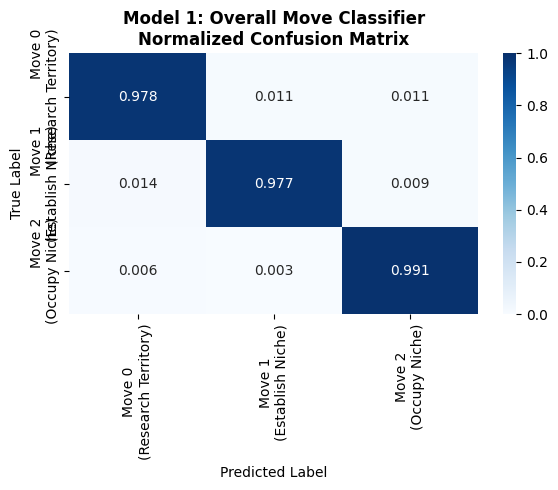

Saved: confusion_matrix_model1.png


In [ ]:
_, _, test1 = make_split(full_df)
print(f'Test set: {len(test1)} sentences')

infer1, ik1, ok1 = load_saved_model(
    'stormsidali2001/IMRAD_introduction_moves_classifier')

raw1    = batch_predict(infer1, ik1, ok1, test1['sentence'].to_numpy())
y_pred1 = np.argmax(raw1, axis=1)
y_true1 = test1['gemini_move'].values

print(classification_report(y_true1, y_pred1,
      target_names=['Move 0', 'Move 1', 'Move 2']))

cm1 = confusion_matrix(y_true1, y_pred1, normalize='true')
plot_and_save(
    cm1,
    ['Move 0\n(Research Territory)', 'Move 1\n(Establish Niche)', 'Move 2\n(Occupy Niche)'],
    'Model 1: Overall Move Classifier\nNormalized Confusion Matrix',
    'Blues', 'confusion_matrix_model1.png', (8, 7))

## 6. Model 2 — Move 0 sub-move specialist

Classifies Move 0 sentences into two sub-moves: **0.0** (Establish importance/relevance of the field) and **0.1** (Review prior research). Trained exclusively on Move 0 sentences from the V3 dataset.

Classes: ['0.0' '0.1']
Test set: 5647 sentences
Loading Model 2...


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

  input_key='text'  output_key='classifier'
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89      2765
         0.1       0.88      0.92      0.90      2882

    accuracy                           0.90      5647
   macro avg       0.90      0.90      0.90      5647
weighted avg       0.90      0.90      0.90      5647



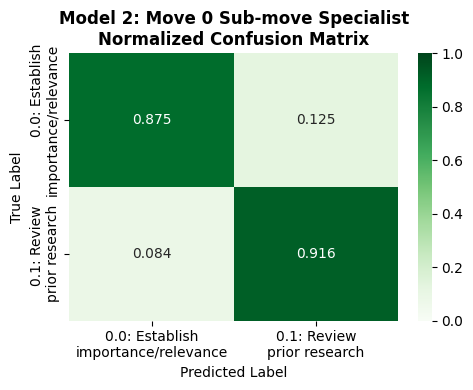

Saved: confusion_matrix_model2_move0.png


In [ ]:
df2 = full_df[full_df['gemini_move'] == 0].copy()
df2 = df2.sort_values(by='move_sub_move_gemini')
le2 = preprocessing.LabelEncoder()
df2['encoded'] = le2.fit_transform(df2['move_sub_move_gemini'])

_, _, test2 = make_split(df2)
print(f'Test set: {len(test2)} sentences  |  Classes: {list(le2.classes_)}')

infer2, ik2, ok2 = load_saved_model(
    'stormsidali2001/IMRAD-introduction-move-zero-sub-moves-classifier')

raw2    = batch_predict(infer2, ik2, ok2, test2['sentence'].to_numpy())
y_pred2 = np.argmax(raw2, axis=1)
y_true2 = test2['encoded'].values

print(classification_report(y_true2, y_pred2,
      target_names=[str(c) for c in le2.classes_]))

cm2 = confusion_matrix(y_true2, y_pred2, normalize='true')
plot_and_save(
    cm2,
    ['0.0: Establish\nimportance/relevance', '0.1: Review\nprior research'],
    'Model 2: Move 0 Sub-move Specialist\nNormalized Confusion Matrix',
    'Greens', 'confusion_matrix_model2_move0.png', (7, 5))

## 7. Model 3 — Move 1 sub-move specialist

Classifies Move 1 sentences into four sub-moves: **1.0** (Claim a flaw in prior work), **1.1** (Highlight a gap), **1.2** (Raise an unclear question), **1.3** (Extend prior research). These are the most rhetorically similar sub-moves in the taxonomy.

Classes: ['1.0' '1.1' '1.2' '1.3']
Test set: 5561 sentences
Loading Model 3...


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

  input_key='text'  output_key='classifier'
              precision    recall  f1-score   support

         1.0       0.97      0.97      0.97      1454
         1.1       0.92      0.92      0.92      1422
         1.2       0.94      0.93      0.94      1317
         1.3       0.95      0.96      0.96      1368

    accuracy                           0.95      5561
   macro avg       0.95      0.95      0.95      5561
weighted avg       0.95      0.95      0.95      5561



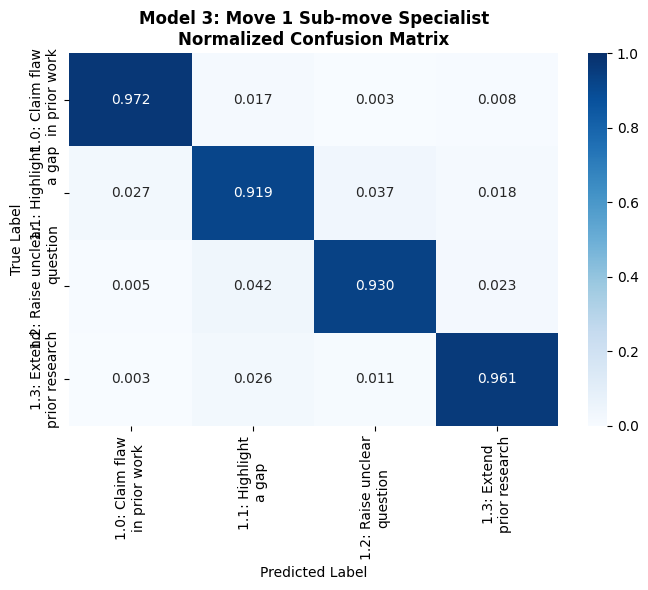

Saved: confusion_matrix_model3_move1.png


In [ ]:
df3 = full_df[full_df['gemini_move'] == 1].copy()
df3 = df3.sort_values(by='move_sub_move_gemini')
le3 = preprocessing.LabelEncoder()
df3['encoded'] = le3.fit_transform(df3['move_sub_move_gemini'])

_, _, test3 = make_split(df3)
print(f'Test set: {len(test3)} sentences  |  Classes: {list(le3.classes_)}')

infer3, ik3, ok3 = load_saved_model(
    'stormsidali2001/IMRAD-introduction-move-one-sub-moves-classifier')

raw3    = batch_predict(infer3, ik3, ok3, test3['sentence'].to_numpy())
y_pred3 = np.argmax(raw3, axis=1)
y_true3 = test3['encoded'].values

print(classification_report(y_true3, y_pred3,
      target_names=[str(c) for c in le3.classes_]))

cm3 = confusion_matrix(y_true3, y_pred3, normalize='true')
plot_and_save(
    cm3,
    ['1.0: Claim flaw\nin prior work', '1.1: Highlight\na gap',
     '1.2: Raise unclear\nquestion', '1.3: Extend\nprior research'],
    'Model 3: Move 1 Sub-move Specialist\nNormalized Confusion Matrix',
    'Blues', 'confusion_matrix_model3_move1.png', (9, 8))

## 8. Model 4 — Move 2 sub-move specialist

Classifies Move 2 sentences into five sub-moves: **2.0** (State purpose/aim), **2.1** (State hypothesis), **2.2** (Share findings), **2.3** (Elaborate value), **2.4** (Outline paper structure). This is the most granular classifier in the hierarchy.

Classes: ['2.0' '2.1' '2.2' '2.3' '2.4']
Test set: 5765 sentences
Loading Model 4...


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

  input_key='text'  output_key='classifier'
              precision    recall  f1-score   support

         2.0       0.97      0.99      0.98      1398
         2.1       0.99      0.97      0.98      1133
         2.2       0.95      0.96      0.96      1164
         2.3       0.96      0.95      0.95      1172
         2.4       1.00      1.00      1.00       898

    accuracy                           0.97      5765
   macro avg       0.97      0.97      0.97      5765
weighted avg       0.97      0.97      0.97      5765



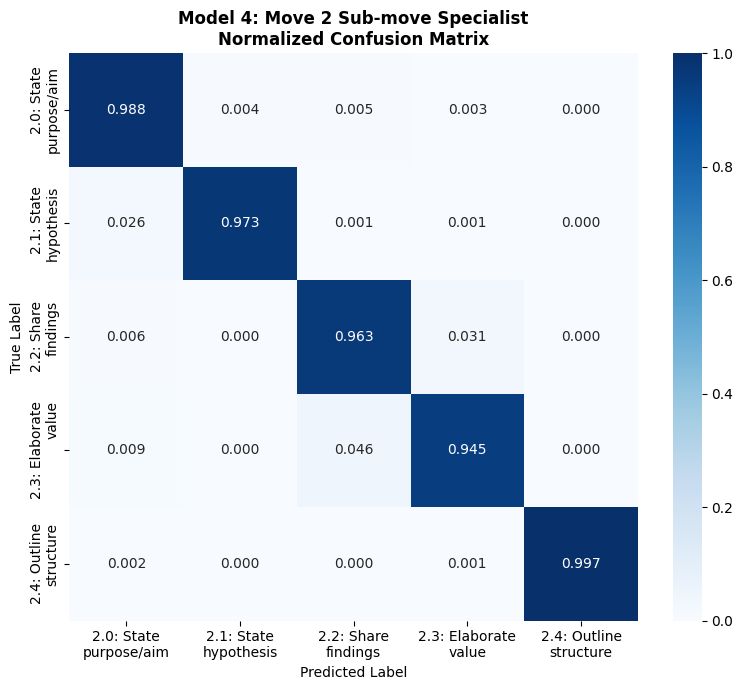

Saved: confusion_matrix_model4_move2.png


In [ ]:
df4 = full_df[full_df['gemini_move'] == 2].copy()
df4 = df4.sort_values(by='move_sub_move_gemini')
le4 = preprocessing.LabelEncoder()
df4['encoded'] = le4.fit_transform(df4['move_sub_move_gemini'])

_, _, test4 = make_split(df4)
print(f'Test set: {len(test4)} sentences  |  Classes: {list(le4.classes_)}')

infer4, ik4, ok4 = load_saved_model(
    'stormsidali2001/IMRAD-introduction-move-two-sub-moves-classifier')

raw4    = batch_predict(infer4, ik4, ok4, test4['sentence'].to_numpy())
y_pred4 = np.argmax(raw4, axis=1)
y_true4 = test4['encoded'].values

print(classification_report(y_true4, y_pred4,
      target_names=[str(c) for c in le4.classes_]))

cm4 = confusion_matrix(y_true4, y_pred4, normalize='true')
plot_and_save(
    cm4,
    ['2.0: State\npurpose/aim', '2.1: State\nhypothesis',
     '2.2: Share\nfindings', '2.3: Elaborate\nvalue', '2.4: Outline\nstructure'],
    'Model 4: Move 2 Sub-move Specialist\nNormalized Confusion Matrix',
    'Blues', 'confusion_matrix_model4_move2.png', (9, 8))

## 9. Download figures

Downloads the four confusion matrix PNGs to your local machine. Place them in the `figures/` directory of the LaTeX project.

In [ ]:
from google.colab import files

for fname in [
    'confusion_matrix_model1.png',
    'confusion_matrix_model2_move0.png',
    'confusion_matrix_model3_move1.png',
    'confusion_matrix_model4_move2.png',
]:
    files.download(fname)